In [78]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import os

In [79]:
data_kc = pd.read_csv("kc_house_data.csv")
data_kc

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [80]:
data_kc["Intercepto"] = 1

data_kc = data_kc[["Intercepto",
                   "bedrooms",      
                   "bathrooms",     
                   "sqft_living",   
                   "sqft_lot",      
                   "floors",       
                   "waterfront",    
                   "view",         
                   "condition",     
                   "grade",         
                   "yr_built",     
                   "yr_renovated",  
                   "price"]]    
print(data_kc.shape)
data_kc.head()

(21613, 13)


,Intercepto,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,yr_built,yr_renovated,price
0,1,3,1.00,1180,5650,1.0,0,0,3,7,1955,0,221900.0
1,1,3,2.25,2570,7242,2.0,0,0,3,7,1951,1991,538000.0
2,1,2,1.00,770,10000,1.0,0,0,3,6,1933,0,180000.0
3,1,4,3.00,1960,5000,1.0,0,0,5,7,1965,0,604000.0
4,1,3,2.00,1680,8080,1.0,0,0,3,8,1987,0,510000.0


In [81]:
Xdata = data_kc[["Intercepto", "bedrooms", "bathrooms", "sqft_living",
                 "sqft_lot", "floors", "waterfront", "view", "condition",
                 "grade", "yr_built", "yr_renovated"]].values
Ydata = data_kc[["price"]].values

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(Xdata, Ydata, test_size=0.3, random_state=1)

In [84]:
X = X_train
Y = Y_train

In [85]:
X.shape[0]

15129

In [86]:
X.shape[1]

12

In [87]:
np.set_printoptions(formatter={"float_kind": "{:f}".format})

In [88]:
XT_X = np.matmul(np.matrix.transpose(X), X)
XT_X

array([[15129.000000, 50963.000000, 32017.000000, 31442387.000000,
        230231424.000000, 22665.000000, 116.000000, 3505.000000,
        51592.000000, 115894.000000, 29820815.000000, 1271248.000000],
       [50963.000000, 184941.000000, 113274.250000, 113202849.000000,
        792701993.000000, 77591.000000, 372.000000, 12596.000000,
        174087.000000, 396101.000000, 100513486.000000, 4378090.000000],
       [32017.000000, 113274.250000, 76568.375000, 74367338.750000,
        529228587.750000, 51082.750000, 306.000000, 9001.500000,
        108207.500000, 254161.750000, 63280042.500000, 2920942.750000],
       [31442387.000000, 113202849.000000, 74367338.750000,
        77688746971.000000, 575423643809.000000, 49691571.000000,
        358581.000000, 10127227.000000, 106683065.000000,
        253007293.000000, 62104027960.000000, 2916435652.000000],
       [230231424.000000, 792701993.000000, 529228587.750000,
        575423643809.000000, 31855025051772.000000, 342386937.500000,
 

In [89]:
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[0.573802, -0.000767, 0.004826, -0.000001, 0.000000, 0.002841,
        0.001225, -0.001075, -0.003955, 0.000928, -0.000292, -0.000005],
       [-0.000767, 0.000122, -0.000040, -0.000000, 0.000000, 0.000009,
        0.000058, 0.000010, -0.000007, 0.000020, 0.000000, 0.000000],
       [0.004826, -0.000040, 0.000359, -0.000000, 0.000000, -0.000083,
        0.000022, -0.000010, -0.000020, -0.000012, -0.000002, -0.000000],
       [-0.000001, -0.000000, -0.000000, 0.000000, -0.000000, 0.000000,
        -0.000000, -0.000000, -0.000000, -0.000000, 0.000000, 0.000000],
       [0.000000, 0.000000, 0.000000, -0.000000, 0.000000, 0.000000,
        0.000000, -0.000000, -0.000000, 0.000000, -0.000000, -0.000000],
       [0.002841, 0.000009, -0.000083, 0.000000, 0.000000, 0.000358,
        -0.000053, 0.000013, 0.000031, -0.000039, -0.000002, -0.000000],
       [0.001225, 0.000058, 0.000022, -0.000000, 0.000000, -0.000053,
        0.010478, -0.000485, -0.000029, 0.000038, -0.000001, -0.000000],

In [90]:
XT_Y = np.matmul(np.matrix.transpose(X), Y)
XT_Y

array([[8134792844.000000],
       [28921660282.000000],
       [19344041227.500000],
       [20285899254544.000000],
       [142407378785985.000000],
       [12932928855.500000],
       [186574092.000000],
       [3471948304.000000],
       [27861195467.000000],
       [66500354540.000000],
       [16042657850839.000000],
       [956236284337.000000]])

In [91]:
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[6074653.061637],
       [-34257.273277],
       [42803.911738],
       [162.998524],
       [-0.238742],
       [26978.598839],
       [560108.261979],
       [43239.757136],
       [17904.785997],
       [123616.337176],
       [-3506.170556],
       [12.114642]])

In [102]:
TSS = np.matmul(np.matrix.transpose(Y), Y) - len(Y) * (Y.mean() ** 2)
TSS

array([[1900668073054776.000000]])

In [103]:
ESS = np.matmul(np.matmul(np.matrix.transpose(betas), np.matrix.transpose(X)),
                np.matmul(X, betas)) - len(Y) * (Y.mean() ** 2)
ESS

array([[1238009460757957.000000]])

In [104]:
RSS = TSS - ESS
RSS

array([[662658612296819.000000]])

In [105]:
RSq = 1 - RSS / TSS
RSq

array([[0.651355]])

In [106]:
n = X.shape[0]
k = X.shape[1] - 1   
RSqAj = 1 - (RSS / (n - k - 1)) / (TSS / (n - 1))
RSqAj

array([[0.651101]])

In [107]:
import statsmodels.api as sm

regressor = sm.OLS(Y, X).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     2567.
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        23:08:34   Log-Likelihood:            -2.0682e+05
No. Observations:               15129   AIC:                         4.137e+05
Df Residuals:                   15117   BIC:                         4.138e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.075e+06   1.59e+05     38.303      0.0

In [108]:
Y_pred = np.matmul(X_test, betas)
Y_pred

array([[716402.386388],
       [315090.580795],
       [850246.463264],
       ...,
       [357535.990664],
       [2116332.909409],
       [880304.483146]], shape=(6484, 1))

In [109]:
Resid = Y_test - Y_pred
Resid

array([[-257402.386388],
       [129909.419205],
       [206753.536736],
       ...,
       [-127535.990664],
       [-436332.909409],
       [-587304.483146]], shape=(6484, 1))

array([[<Axes: title={'center': '0'}>]], dtype=object)

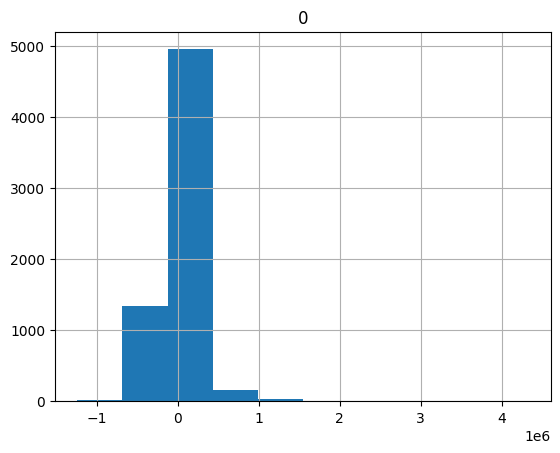

In [110]:
df = pd.DataFrame(Resid)
df.hist()

In [111]:
from sklearn.metrics import r2_score
from sklearn import metrics

print("Coeficientes R Cuadrado", r2_score(Y_test, Y_pred))

Coeficientes R Cuadrado 0.6524713796705552
